# Họ và Tên: Nguyễn Tuấn Kiệt
# MSSV: 207CT28052

### Câu 1 (2 điểm): Cho một ảnh bất kỳ (tên ảnh do sinh viên tự đặt, ví dụ: `my_image.jpg`) và thực hiện các yêu cầu sau:

* Viết chương trình sử dụng median filter để làm mịn ảnh. (0.5 điểm)  
* Viết chương trình sử dụng Sobel filter để xác định biên của hình ảnh. (0.5 điểm)  
* Đổi màu ảnh bằng cách hoán đổi thứ tự các kênh màu (ví dụ: BGR → GRB hoặc GBR...) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm)  
* Chuyển ảnh sang không gian màu LAB và tách riêng 3 kênh L, A, B, lưu thành ảnh grayscale tương ứng (`[ten_anh]_L.jpg`, `[ten_anh]_A.jpg`, `[ten_anh]_B.jpg`). (0.5 điểm)


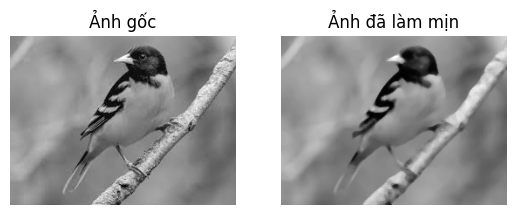

In [2]:
# Viết chương trình sử dụng median filter để làm mịn ảnh. (0.5 điểm)  
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as sn
import matplotlib.pyplot as plt


img = iio.imread('bird.png', mode="L").astype(np.uint8)


smoothed = sn.median_filter(img, size=5)


plt.subplot(1, 2, 1)
plt.title("Ảnh gốc")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Ảnh đã làm mịn")
plt.imshow(smoothed, cmap='gray')
plt.axis('off')

plt.show()


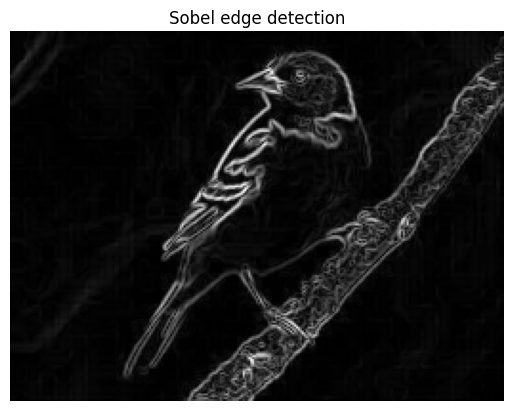

In [3]:
# Viết chương trình sử dụng Sobel filter để xác định biên của hình ảnh. (0.5 điểm)  
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as sn
from skimage import filters
import matplotlib.pylab as plt
import colorsys

a = iio.imread('bird.png', mode='L') 

b = filters.sobel(a) 

b = (b / np.max(b) * 255).astype(np.uint8)

iio.imsave('bird_sobel_filter_edge_detection.png', b)

plt.imshow(b, cmap='gray')
plt.axis('off')
plt.title('Sobel edge detection')
plt.show()





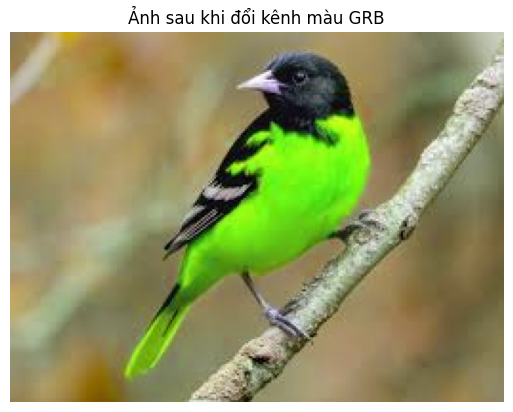

In [4]:
#Đổi màu ảnh bằng cách hoán đổi thứ tự các kênh màu (ví dụ: BGR → GRB hoặc GBR...) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm)  
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt

rgb = iio.imread('bird.png')

swapped = rgb[:, :, [1, 0, 2]]  

iio.imsave('bird_swapped.jpg', swapped)

plt.imshow(swapped)
plt.axis('off')
plt.title('Ảnh sau khi đổi kênh màu GRB')
plt.show()


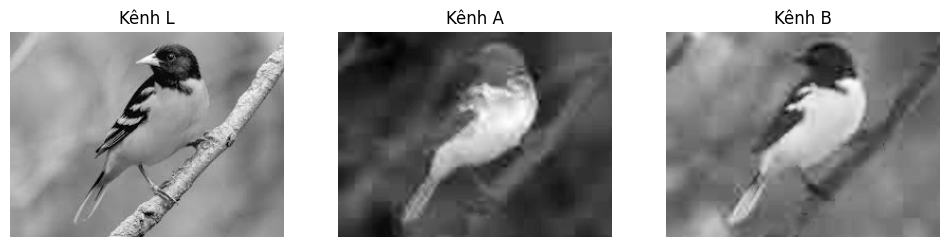

In [5]:
#Chuyển ảnh sang không gian màu LAB và tách riêng 3 kênh L, A, B, lưu thành ảnh grayscale tương ứng (`[ten_anh]_L.jpg`, `[ten_anh]_A.jpg`, `[ten_anh]_B.jpg`). (0.5 điểm)
import numpy as np
import imageio.v2 as iio
from skimage import color
import matplotlib.pyplot as plt

# Đọc ảnh màu RGB
rgb = iio.imread('bird.png')

# Chuyển ảnh từ RGB sang LAB
lab = color.rgb2lab(rgb)

# Tách 3 kênh L, A, B
L = lab[:, :, 0]
A = lab[:, :, 1]
B = lab[:, :, 2]

# Chuẩn hóa từng kênh để lưu dưới dạng ảnh xám (0–255)
L_norm = ((L - L.min()) / (L.max() - L.min()) * 255).astype(np.uint8)
A_norm = ((A - A.min()) / (A.max() - A.min()) * 255).astype(np.uint8)
B_norm = ((B - B.min()) / (B.max() - B.min()) * 255).astype(np.uint8)

# Lưu từng kênh
iio.imsave('bird_L.jpg', L_norm)
iio.imsave('bird_A.jpg', A_norm)
iio.imsave('bird_B.jpg', B_norm)

# Hiển thị minh họa (tùy chọn, không bắt buộc nếu chỉ cần lưu)
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(L_norm, cmap='gray'); axs[0].set_title('Kênh L')
axs[1].imshow(A_norm, cmap='gray'); axs[1].set_title('Kênh A')
axs[2].imshow(B_norm, cmap='gray'); axs[2].set_title('Kênh B')
for ax in axs:
    ax.axis('off')
plt.show()


### Câu 2 (4 điểm) Viết một chương trình Python sử dụng OpenCV để tạo menu tương tác cho phép người dùng chọn các kỹ thuật lọc và xử lý ảnh nâng cao từ một danh sách, áp dụng đồng thời cho nhiều ảnh.

### Yêu cầu:

1. Menu gồm:  
* Gaussian Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
* Median Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
* Bilateral Filter (tham số ngẫu nhiên) (0.5 điểm)  
* Canny Edge Detection (thresholds ngẫu nhiên 50–150) (0.5 điểm)  
* Erosion (kernel 2x2 đến 5x5 ngẫu nhiên) (0.5 điểm)  
* Dilation (tương tự Erosion) (0.5 điểm)

2. Chương trình xử lý đồng thời 3 ảnh bất kỳ do sinh viên tự chọn (có thể chọn bằng đường dẫn file hoặc nhập tên ảnh tùy ý). (0.5 điểm)

3. Phím tương ứng để kích hoạt các phương pháp xử lý:  
* B: Gaussian Blur  
* M: Median Blur  
* F: Bilateral Filter  
* E: Canny Edge  
* R: Erosion  
* D: Dilation (0.5 điểm)

4. Lưu file kết quả với định dạng: `result_[phương pháp]_[tên ảnh gốc].jpg`  
   Ví dụ: `result_blur_dog.jpg`, `result_canny_image2.jpg` (0.5 điểm)


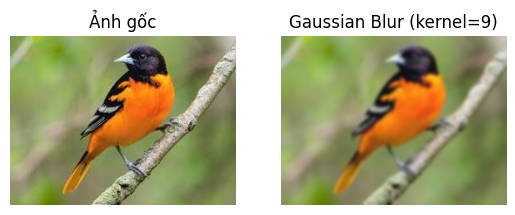

In [6]:
# Gaussian Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import cv2
import random
import colorsys

# đọc ảnh RGB
img = iio.imread('bird.png')

# chuyển sang BGR để dùng với OpenCV
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# kernel size ngẫu nhiên lẻ từ 3 đến 11
k = random.choice([3, 5, 7, 9, 11])

# áp dụng Gaussian Blur
blur = cv2.GaussianBlur(img_bgr, (k, k), 0)

# chuyển lại RGB để hiển thị bằng matplotlib
blur_rgb = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)


iio.imsave('bird_gaussian_blur.jpg', blur_rgb)


plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blur_rgb)
plt.title(f'Gaussian Blur (kernel={k})')
plt.axis('off')

plt.show()



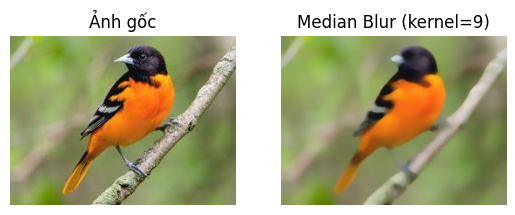

In [7]:
#Median Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import cv2
import colorsys

# đọc ảnh RGB
img = iio.imread('bird.png')

# chuyển sang BGR để dùng với OpenCV
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# kernel size cố định 9 (9x9)
k = 9

# áp dụng Median Blur
blur = cv2.medianBlur(img_bgr, k)

# chuyển lại RGB để hiển thị đúng màu
blur_rgb = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)

# lưu ảnh kết quả
iio.imsave('bird_median_blur.jpg', blur_rgb)

# hiển thị ảnh gốc và ảnh đã làm mờ
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blur_rgb)
plt.title(f'Median Blur (kernel={k})')
plt.axis('off')

plt.show()



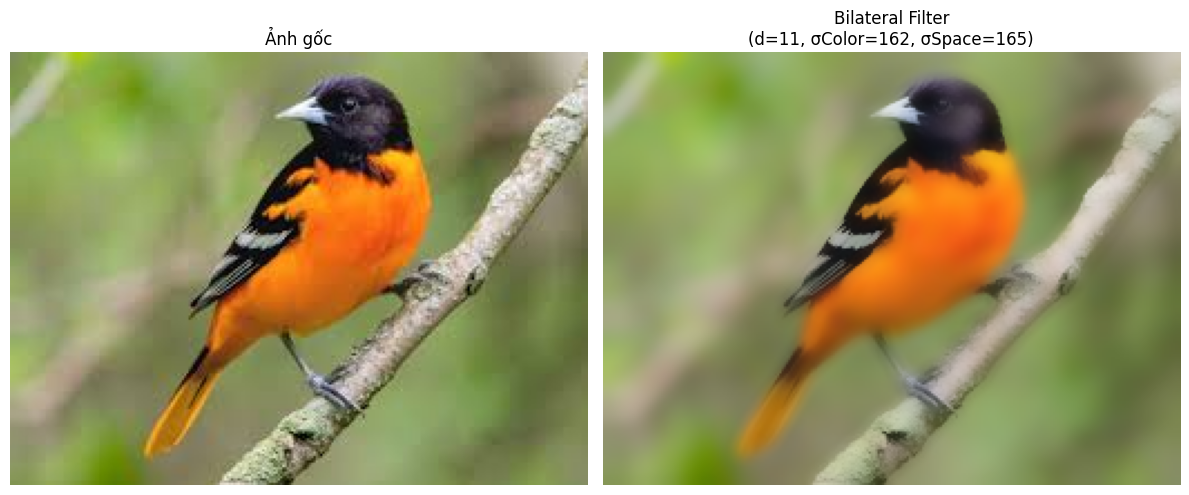

In [8]:
#Bilateral Filter (tham số ngẫu nhiên) (0.5 điểm)  
import numpy as np
import imageio.v2 as iio
import matplotlib.pylab as plt
import cv2
import random

# Đọc ảnh RGB
img = iio.imread('bird.png')

# Chuyển sang BGR để dùng với OpenCV
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# Tham số ngẫu nhiên nhưng đảm bảo đủ lớn để thấy rõ hiệu ứng
d = random.choice([7, 9, 11])                      # đường kính kernel
sigmaColor = random.randint(150, 250)              # ảnh hưởng màu sắc
sigmaSpace = random.randint(150, 250)              # ảnh hưởng không gian

# Áp dụng Bilateral Filter
bilateral = cv2.bilateralFilter(img_bgr, d, sigmaColor, sigmaSpace)

# Chuyển lại RGB để hiển thị
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB)

# Lưu ảnh kết quả
iio.imsave('bird_bilateral_filter.jpg', bilateral_rgb)

# Hiển thị ảnh gốc và ảnh sau khi lọc
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bilateral_rgb)
plt.title(f'Bilateral Filter\n(d={d}, σColor={sigmaColor}, σSpace={sigmaSpace})')
plt.axis('off')

plt.tight_layout()
plt.show()



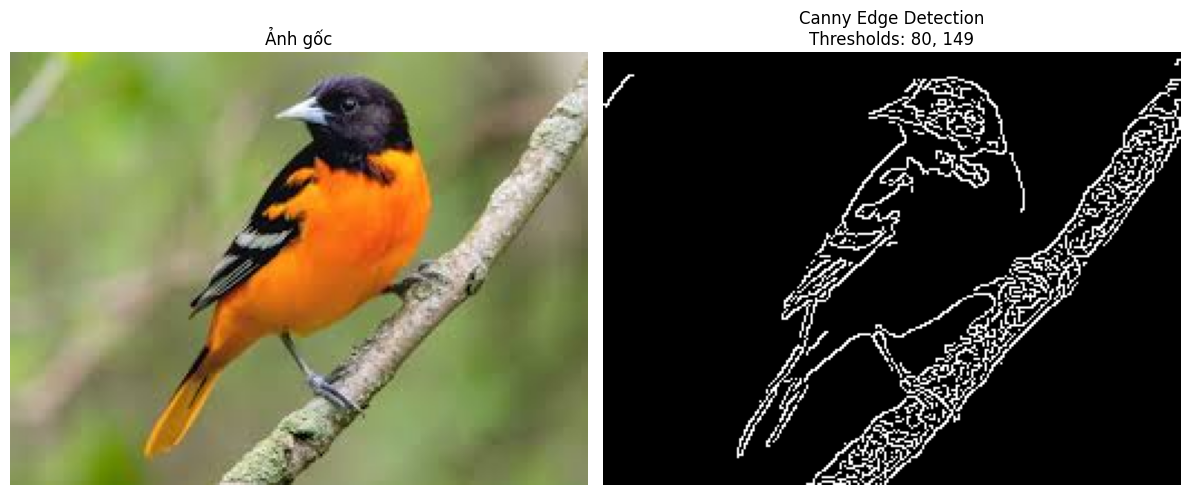

In [9]:
#Canny Edge Detection (thresholds ngẫu nhiên 50–150) (0.5 điểm)  
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
import cv2
import random

# Đọc ảnh RGB và chuyển sang grayscale
img = iio.imread('bird.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Tạo ngưỡng ngẫu nhiên trong khoảng 50–150
threshold1 = random.randint(50, 100)
threshold2 = random.randint(threshold1 + 10, 150)  # threshold2 phải lớn hơn threshold1

# Áp dụng Canny Edge Detection
edges = cv2.Canny(img_gray, threshold1, threshold2)

# Lưu ảnh kết quả
iio.imsave('bird_canny_edge.jpg', edges)

# Hiển thị ảnh gốc và ảnh biên cạnh nhau
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title(f'Canny Edge Detection\nThresholds: {threshold1}, {threshold2}')
plt.axis('off')

plt.tight_layout()
plt.show()


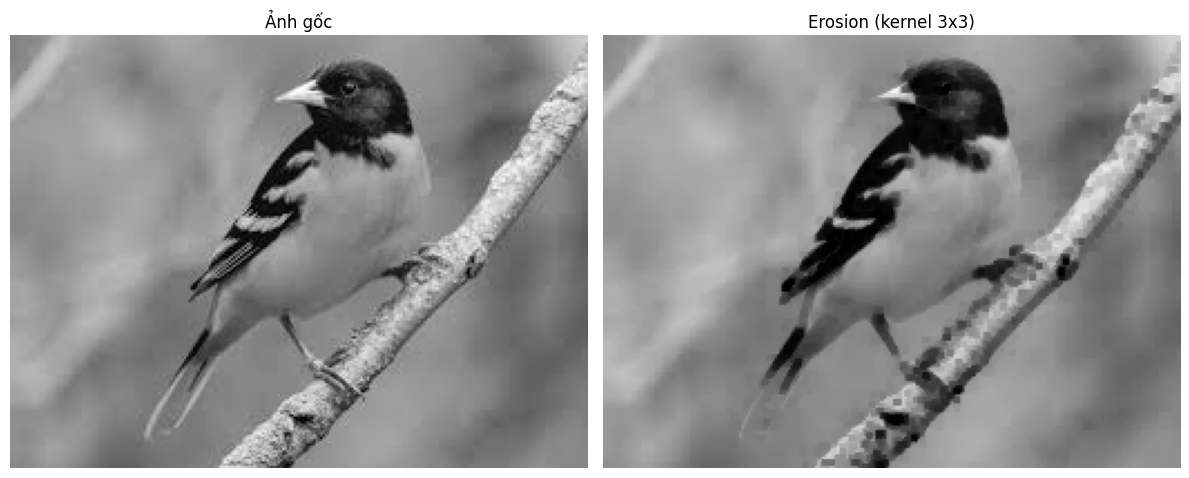

In [10]:
#Erosion (kernel 2x2 đến 5x5 ngẫu nhiên) (0.5 điểm)  
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
import cv2
import random

# Đọc ảnh RGB và chuyển sang ảnh grayscale
img = iio.imread('bird.png')
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Tạo kernel ngẫu nhiên từ 2x2 đến 5x5
k = random.randint(2, 5)
kernel = np.ones((k, k), np.uint8)

# Áp dụng Erosion
erosion = cv2.erode(gray, kernel, iterations=1)

# Lưu ảnh kết quả
iio.imsave('bird_erosion.jpg', erosion)

# Hiển thị ảnh gốc và ảnh erosion
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(erosion, cmap='gray')
plt.title(f'Erosion (kernel {k}x{k})')
plt.axis('off')

plt.tight_layout()
plt.show()


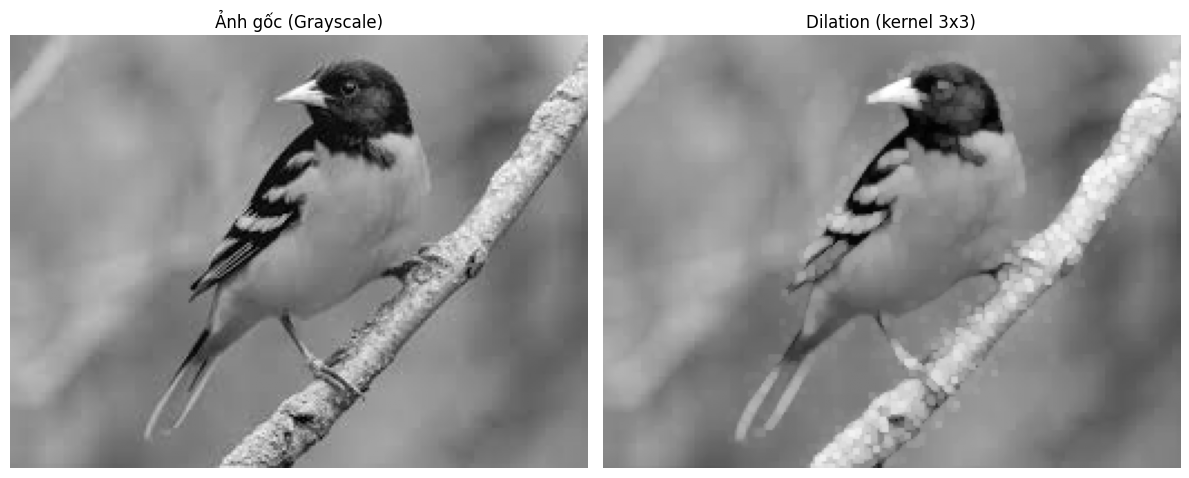

In [11]:
# Dilation (tương tự Erosion) (0.5 điểm)
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
import cv2
import random

# Đọc ảnh RGB và chuyển sang grayscale
img = iio.imread('bird.png')
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Tạo kernel ngẫu nhiên từ 2x2 đến 5x5
k = random.randint(2, 5)
kernel = np.ones((k, k), np.uint8)

# Áp dụng Dilation
dilation = cv2.dilate(gray, kernel, iterations=1)

# Lưu ảnh kết quả
iio.imsave('bird_dilation.jpg', dilation)

# Hiển thị ảnh gốc và ảnh sau khi giãn
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Ảnh gốc (Grayscale)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dilation, cmap='gray')
plt.title(f'Dilation (kernel {k}x{k})')
plt.axis('off')

plt.tight_layout()
plt.show()


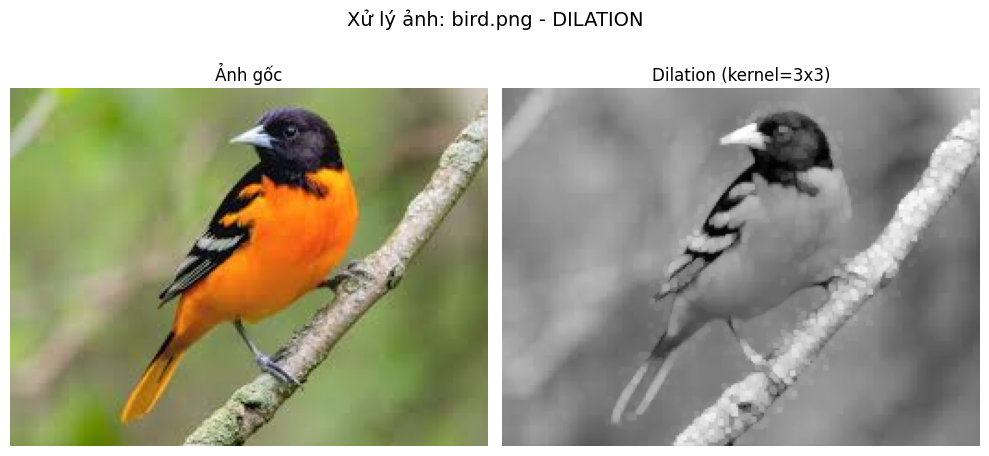

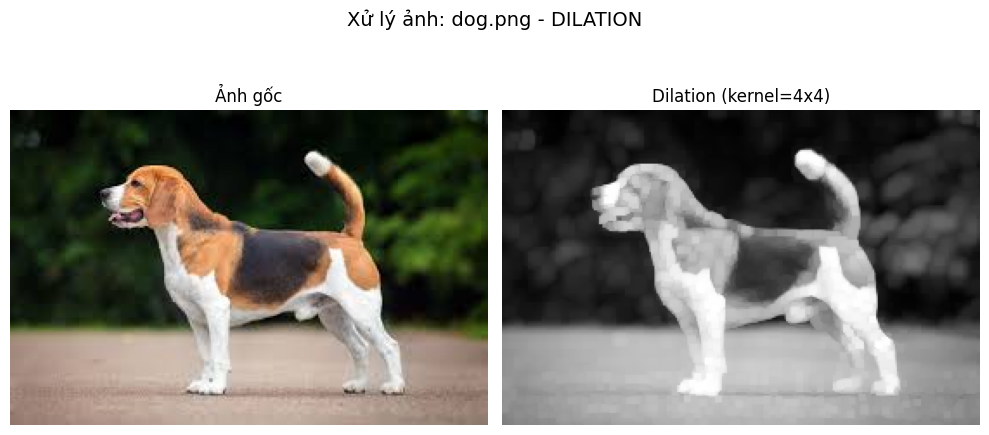

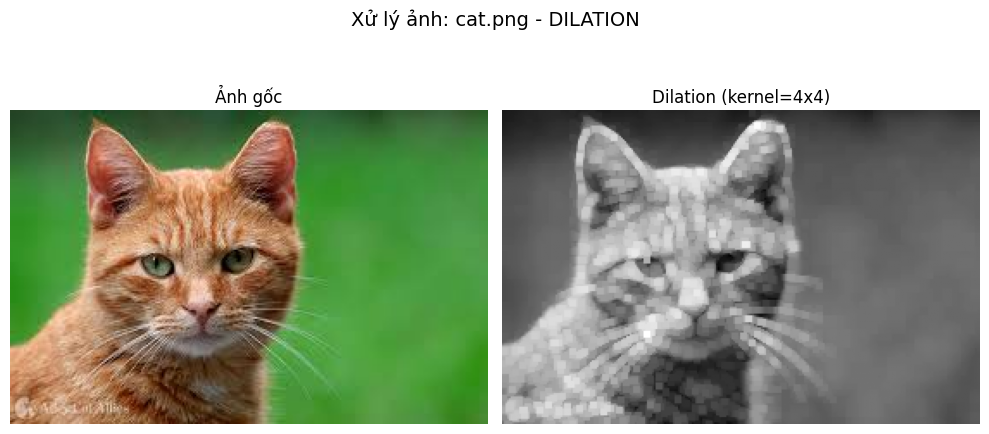

In [13]:
# 2. Chương trình xử lý đồng thời 3 ảnh bất kỳ do sinh viên tự chọn (có thể chọn bằng đường dẫn file hoặc nhập tên ảnh tùy ý). (0.5 điểm)
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
import cv2
import random
import os

# === Danh sách ảnh từ người dùng nhập ===
file_names = []
for i in range(3):
    name = input(f"Nhập tên file ảnh thứ {i+1} (VD: bird.png): ").strip()
    if not os.path.exists(name):
        print(f"Ảnh '{name}' không tồn tại, bỏ qua.")
        continue
    file_names.append(name)

# === Hàm xử lý mỗi ảnh: chọn ngẫu nhiên 1 filter để áp dụng ===
def process_image(filename):
    img = iio.imread(filename)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Chọn ngẫu nhiên 1 kỹ thuật xử lý ảnh
    method = random.choice(['bilateral', 'erosion', 'dilation'])
    
    if method == 'bilateral':
        d = random.choice([5, 7, 9])
        sigmaColor = random.randint(50, 150)
        sigmaSpace = random.randint(50, 150)
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        result = cv2.bilateralFilter(img_bgr, d, sigmaColor, sigmaSpace)
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        title = f'Bilateral (d={d}, σC={sigmaColor}, σS={sigmaSpace})'

    elif method == 'erosion':
        k = random.randint(2, 5)
        kernel = np.ones((k, k), np.uint8)
        result = cv2.erode(gray, kernel, iterations=1)
        title = f'Erosion (kernel={k}x{k})'

    elif method == 'dilation':
        k = random.randint(2, 5)
        kernel = np.ones((k, k), np.uint8)
        result = cv2.dilate(gray, kernel, iterations=1)
        title = f'Dilation (kernel={k}x{k})'

    return img, result, title, method

# === Hiển thị ảnh gốc và ảnh đã xử lý ===
for fname in file_names:
    original, processed, title, method = process_image(fname)

    plt.figure(figsize=(10, 5))
    plt.suptitle(f'Xử lý ảnh: {fname} - {method.upper()}', fontsize=14)

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Ảnh gốc")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if method in ['erosion', 'dilation']:
        plt.imshow(processed, cmap='gray')
    else:
        plt.imshow(processed)
    plt.title(title)
    plt.axis('off')

    plt.tight_layout()
    plt.show()



Chọn phím để áp dụng kỹ thuật xử lý ảnh:
B - Gaussian Blur
M - Median Blur
F - Bilateral Filter
E - Canny Edge
R - Erosion
D - Dilation



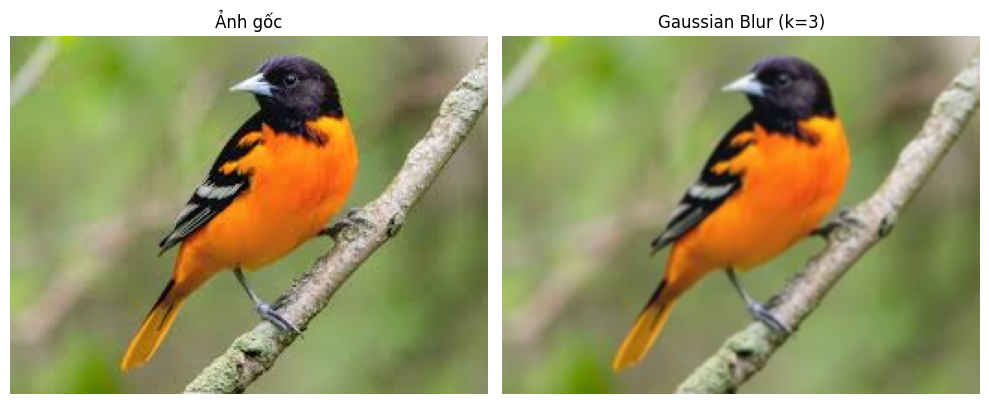

In [14]:
# 3. Phím tương ứng để kích hoạt các phương pháp xử lý:  
# B: Gaussian Blur  
# M: Median Blur  
# F: Bilateral Filter  
# E: Canny Edge  
# R: Erosion  
# D: Dilation (0.5 điểm)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Đọc ảnh gốc
img = cv2.imread('bird.png')
if img is None:
    print("Không tìm thấy ảnh.")
    exit()

# Chuyển sang RGB để hiển thị đúng màu bằng matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("""
Chọn phím để áp dụng kỹ thuật xử lý ảnh:
B - Gaussian Blur
M - Median Blur
F - Bilateral Filter
E - Canny Edge
R - Erosion
D - Dilation
""")

key = input("Nhập phím xử lý: ").upper()

result = None
title = ""

if key == 'B':
    k = random.choice([3, 5, 7, 9, 11])
    result = cv2.GaussianBlur(img_rgb, (k, k), 0)
    title = f'Gaussian Blur (k={k})'

elif key == 'M':
    k = random.choice([3, 5, 7, 9, 11])
    result = cv2.medianBlur(img_rgb, k)
    title = f'Median Blur (k={k})'

elif key == 'F':
    d = random.choice([5, 7, 9])
    sigmaColor = random.randint(50, 150)
    sigmaSpace = random.randint(50, 150)
    result = cv2.bilateralFilter(img_rgb, d, sigmaColor, sigmaSpace)
    title = f'Bilateral (d={d}, σC={sigmaColor}, σS={sigmaSpace})'

elif key == 'E':
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    t1, t2 = sorted(random.sample(range(50, 151), 2))
    result = cv2.Canny(gray, t1, t2)
    title = f'Canny Edge (T1={t1}, T2={t2})'

elif key == 'R':
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    k = random.randint(2, 5)
    kernel = np.ones((k, k), np.uint8)
    result = cv2.erode(gray, kernel, 1)
    title = f'Erosion (k={k})'

elif key == 'D':
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    k = random.randint(2, 5)
    kernel = np.ones((k, k), np.uint8)
    result = cv2.dilate(gray, kernel, 1)
    title = f'Dilation (k={k})'

else:
    print("Phím không hợp lệ.")
    exit()

# Hiển thị bằng matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Ảnh gốc')
plt.axis('off')

plt.subplot(1, 2, 2)
if len(result.shape) == 2:  # Ảnh xám
    plt.imshow(result, cmap='gray')
else:
    plt.imshow(result)
plt.title(title)
plt.axis('off')

plt.tight_layout()
plt.show()



Đã lưu: result_blur_dog.jpg


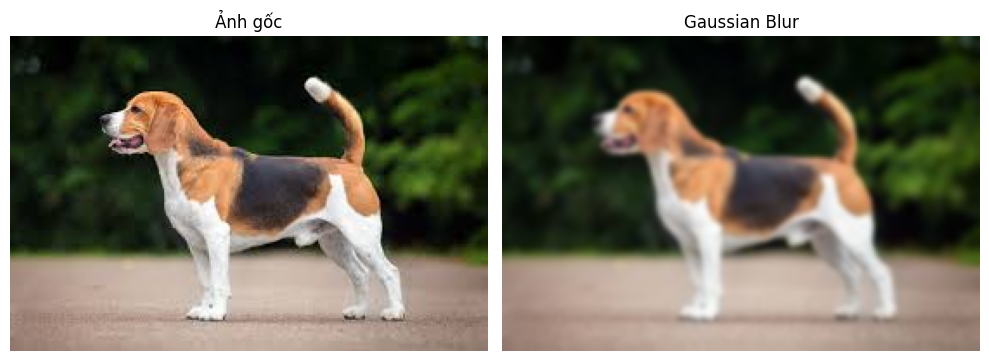

In [15]:
# 4. Lưu file kết quả với định dạng: `result_[phương pháp]_[tên ảnh gốc].jpg`  
  # Ví dụ: `result_blur_dog.jpg`, `result_canny_image2.jpg` (0.5 điểm)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Cấu hình tên ảnh gốc ===
filename = 'dog.png'  # <== bạn đổi tên ảnh ở đây
img = cv2.imread(filename)

# === Xử lý: ví dụ Gaussian Blur ===
method = "blur"
k = 7
blur = cv2.GaussianBlur(img, (k, k), 0)

# === Tạo tên file kết quả ===
base = os.path.splitext(os.path.basename(filename))[0]
save_name = f"result_{method}_{base}.jpg"

# === Lưu kết quả ===
cv2.imwrite(save_name, blur)
print(f"Đã lưu: {save_name}")

# === Hiển thị ảnh gốc và kết quả ===
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()


### Câu 3 (4 điểm) Viết một chương trình Python để xử lý 3 ảnh bất kỳ do sinh viên tự chọn.

* Tăng kích thước ảnh đầu tiên thêm 35 pixel ở mỗi cạnh. (0.5 điểm)  
* Xoay ảnh thứ hai 135 độ và lật ngang. (0.5 điểm)  
* Tăng kích thước ảnh thứ ba lên 5 lần và làm mịn bằng Gaussian blur kernel 9x9. (1.5 điểm)  
* Thay đổi độ sáng và độ tương phản ảnh thứ ba bằng công thức:

$$
I_{out}(x, y) = \alpha \cdot I_{in}(x, y) + \beta
$$

Trong đó:  

$$
\alpha \in [0.5, 2.0], \quad \beta \in [-50, 50]
$$

Giá trị đầu ra cần được giới hạn trong khoảng [0, 255] bằng công thức:

$$
I_{out}(x, y) = \text{clip}(I_{out}(x, y), 0, 255)
$$


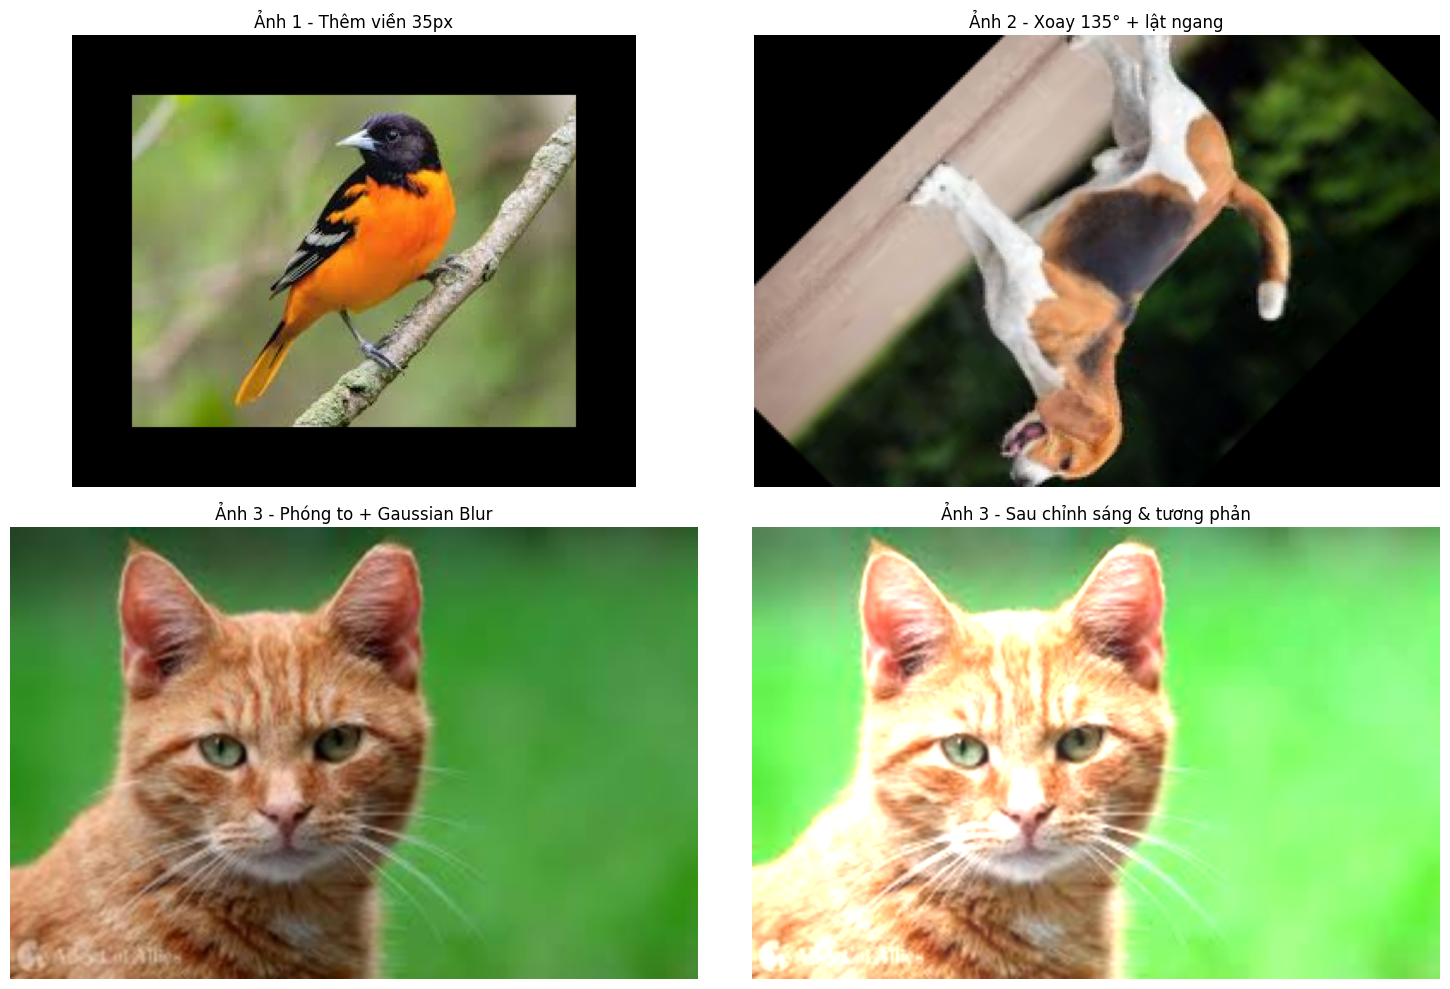

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio

# Đọc 3 ảnh bất kỳ (đặt cùng thư mục với file code)
img1 = cv2.imread('bird.png')
img2 = cv2.imread('dog.png')
img3 = cv2.imread('cat.png')

# Kiểm tra ảnh có đọc được không
assert img1 is not None and img2 is not None and img3 is not None, "Không đọc được ảnh!"

# Chuyển ảnh BGR -> RGB để hiển thị bằng matplotlib
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

# === 1. Tăng kích thước ảnh đầu tiên thêm 35 pixel ở mỗi cạnh ===
bordered = cv2.copyMakeBorder(img1_rgb, 35, 35, 35, 35, cv2.BORDER_CONSTANT, value=[0, 0, 0])

# === 2. Xoay ảnh thứ hai 135 độ và lật ngang ===
(h, w) = img2_rgb.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 135, 1.0)
rotated = cv2.warpAffine(img2_rgb, M, (w, h))
flipped = cv2.flip(rotated, 1)  # lật ngang

# === 3. Phóng to ảnh thứ ba lên 5 lần + Gaussian Blur ===
resized = cv2.resize(img3_rgb, None, fx=5, fy=5, interpolation=cv2.INTER_LINEAR)
blurred = cv2.GaussianBlur(resized, (9, 9), 0)

# === 4. Thay đổi độ sáng và độ tương phản ===
alpha = 1.5   # độ tương phản (0.5 → 2.0)
beta = 30     # độ sáng (-50 → 50)

adjusted = np.clip(alpha * blurred + beta, 0, 255).astype(np.uint8)

# === Hiển thị kết quả ===
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(bordered)
plt.title('Ảnh 1 - Thêm viền 35px')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(flipped)
plt.title('Ảnh 2 - Xoay 135° + lật ngang')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(blurred)
plt.title('Ảnh 3 - Phóng to + Gaussian Blur')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(adjusted)
plt.title('Ảnh 3 - Sau chỉnh sáng & tương phản')
plt.axis('off')

plt.tight_layout()
plt.show()


# Chúc các bạn làm bài may mắn, hi vọng mọi người qua môn tất cả được 10.